In [1]:
import requests
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import gpytorch
from common import get_data, to_tensor
import constant as const
from call_GP import train_GP, ExactGPModel, evaluate_gp, call_model, cal_pos

url = "http://127.0.0.1:80" 
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

print("done")

Using: cuda
done


In [2]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

version = requests.get('{0}/version'.format(url)).json()['payload']
print(version)
inputs = requests.get('{0}/inputs/{1}'.format(url, testid)).json()['payload']
print('TEST CASE INPUTS ---------------------------------------------')
print(inputs.keys())
print('TEST CASE MEASUREMENTS ---------------------------------------')
measurements = requests.get('{0}/measurements/{1}'.format(url, testid)).json()['payload']

{'name': 'bestest_air'}
{'version': '0.8.0'}
TEST CASE INPUTS ---------------------------------------------
dict_keys(['con_oveTSetCoo_activate', 'con_oveTSetCoo_u', 'con_oveTSetHea_activate', 'con_oveTSetHea_u', 'fcu_oveFan_activate', 'fcu_oveFan_u', 'fcu_oveTSup_activate', 'fcu_oveTSup_u'])
TEST CASE MEASUREMENTS ---------------------------------------


In [3]:
step = const.step

data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data_test = data
data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0


pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]


def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))


Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 
cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  
X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

ramp = const.ramp

In [4]:
from scipy.spatial.distance import cdist

def acqui_func(model, U_grid, X_0, X_out, X_tr, y_tr, alpha=0.2, plot=False):
    N = U_grid.shape[0]

    X_cands = torch.cat([X_0.expand(N, -1), U_grid, X_out.expand(N, -1)], dim=1)

    model.eval()
    with torch.no_grad():
        y_preds = model(X_cands).mean.detach().cpu().numpy()

    X_cands_np = X_cands.cpu().numpy()
    X_tr_np    = X_tr.cpu().numpy()
    y_tr_np    = y_tr.cpu().numpy()

    eps   = 1e-5
    dists = cdist(X_cands_np, X_tr_np)
    inv_d = np.exp(-dists) / (dists**2 + eps)
    w_sum = inv_d.sum(axis=1)                      
    w     = inv_d / (w_sum[:, None] + 1e-8)        

    residuals_sq = (y_tr_np[None, :] - y_preds[:, None])**2
    idw_var = (w * residuals_sq).sum(axis=1)

    diversity = (2.0 / np.pi) * np.arctan(1.0 / (w_sum + 1e-8))
    diversity[dists.min(axis=1) < 1e-3] = 0.0

    def norm(a):
        return (a - a.min()) / (a.max() - a.min() + 1e-8)

    scores  = alpha * norm(idw_var) + (1 - alpha) * norm(diversity)
    ind     = int(np.argmax(scores))
    U_optim = U_grid[ind]

    if plot:
        u1_vals = torch.unique(U_grid[:, 0]).cpu().numpy()
        u2_vals = torch.unique(U_grid[:, 1]).cpu().numpy()
        s_map   = np.zeros((len(u2_vals), len(u1_vals)))
        for k in range(N):
            i = np.where(u1_vals == U_grid[k, 0].cpu().numpy())[0][0]
            j = np.where(u2_vals == U_grid[k, 1].cpu().numpy())[0][0]
            s_map[j, i] = scores[k]
        plt.figure(figsize=(6, 5))
        cp = plt.imshow(s_map,
                        extent=[u1_vals.min(), u1_vals.max(),
                                u2_vals.min(), u2_vals.max()],
                        origin="lower", aspect="auto")
        plt.colorbar(cp, label="IDW Acquisition Score")
        plt.scatter(U_optim[0].cpu(), U_optim[1].cpu(), c="red", marker="x", s=100)
        plt.xlabel("u1 (Supply)")
        plt.ylabel("u2 (Airflow)")
        plt.title("IDW Acquisition Landscape")
        plt.show()

    return U_optim


class MPC:
    def __init__(self, X_tr, y_tr, model_path=f'model_GS_GP_{step}m.pth'):
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        self.gp_model = ExactGPModel(X_tr, y_tr, self.likelihood).to(device)
        
        state_dict = torch.load(model_path, map_location=device)
        self.gp_model.load_state_dict(state_dict)
        self.gp_model.eval()
        self.f_best = y_tr.max().item()  
        self.device = device
        self.X_tr = X_tr
        self.y_tr = y_tr

    def mpc_grid_search(self, X_0, X_out, u0_1, u0_2, n_grid, plot=True):
        X_0_norm   = torch.tensor(X_0, dtype=torch.float32, device=self.device).view(1, -1) / 30.0
        x_out_norm = torch.tensor(X_out, dtype=torch.float32, device=self.device).view(1, -1) 
        u1_vals    = torch.linspace(max(u0_1-const.ramp, 0.3), min(u0_1+const.ramp, 1.0), n_grid, device=self.device)
        u2_vals    = torch.linspace(max(u0_2-const.ramp, 0.0), min(u0_2+const.ramp, 1.0), n_grid, device=self.device)
        U_grid     = torch.cartesian_prod(u1_vals, u2_vals)

        if not isinstance(self.X_tr, torch.Tensor):
            self.X_tr = torch.tensor(self.X_tr, dtype=torch.float32, device=self.device)
        if not isinstance(self.y_tr, torch.Tensor):
            self.y_tr = torch.tensor(self.y_tr, dtype=torch.float32, device=self.device)

        best_u = acqui_func(self.gp_model, U_grid, X_0_norm, x_out_norm, self.X_tr, self.y_tr, plot=plot)

        return best_u, {
            'fcu_oveTSup_u':        float(best_u[0] * 40 + 273.15),
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u':         float(best_u[1]),
            'fcu_oveFan_activate':  1
        }

In [5]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':step*60})
start_time_days = y['time']/3600/24
train_GP(X_tr=X_tr, y_tr=y_tr.squeeze(-1), save_path=f'model_IDW_GP_{step}m.pth', ori=0)
evaluate_gp(X_tr, y_tr, X_t, y_t, save_path=f'model_IDW_GP_{step}m.pth')

tensor(0.2775, device='cuda:0')

In [6]:
last_change_day = start_time_days
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {
        'fcu_oveTSup_u': u0_1 * 40 + 273.15,
        'fcu_oveTSup_activate': 1,
        'fcu_oveFan_u': u0_2,
        'fcu_oveFan_activate': 1
        }

x_ref = 25
simulation_time_days = y['time']/3600/24
print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  


ls_rmse = [evaluate_gp(X_tr, y_tr, X_t, y_t, save_path=f'model_IDW_GP_{step}m.pth')]
X_tr_new = X_tr
y_tr_new = y_tr
num_count = const.num_count
n_grid = 10

Simulation time [elapsed days] = 0.00


In [7]:
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    x_out = (y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0
    mpc_controller = MPC(X_tr_new, y_tr_new, model_path=f'model_IDW_GP_{step}m.pth')
    best_u, u = mpc_controller.mpc_grid_search(X_0=x0, X_out=x_out, u0_1=u0_1, u0_2=u0_2, n_grid=n_grid, plot=False)

    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    print("Controller output:", u)

    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    counter += 1

    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add=  to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0

    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)

    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)

    y_tr_n = pos_add.squeeze(-1)   

    X_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0)
    y_tr_new = torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if const.count_data == const.number_of_data:
        train_GP(X_tr=X_tr_new, y_tr=y_tr_new, save_path=f'model_IDW_GP_{step}m.pth', ori=1)
        print("=======retrain GP model=======")
        const.count_data = 0
    const.count_data += 1
    simulation_time_days = y['time']/3600/24
    print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))

    u0_1 = (u['fcu_oveTSup_u']-273.15)/40.0
    u0_2 = u['fcu_oveFan_u']

    rmse = evaluate_gp(X_tr_new, y_tr_new, X_t, y_t, save_path=f'model_IDW_GP_{step}m.pth')

    ls_rmse.append(rmse)
    if counter > num_count:
        break

-------------------------------------------------------------------
Step counter = 0
Controller output: {'fcu_oveTSup_u': 285.1499938964844, 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': 0.699999988079071, 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 1
Controller output: {'fcu_oveTSup_u': 293.1499938964844, 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': 0.8999999761581421, 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 2
Controller output: {'fcu_oveTSup_u': 301.1499938964844, 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': 1.0, 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 3
Controller output: {'fcu_oveTSup_u': 309.1499938964844, 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': 0.800000011920929, 'fcu_oveF

<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
C:\Users\namng\AppData\Local\Temp\ipykernel_22852\1223869731.py:26: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
C:\Users\namng\AppData\Local\Temp\ipykernel_22852\1223869731.py:31: SyntaxWarning: invalid escape sequence '\c'
  axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')


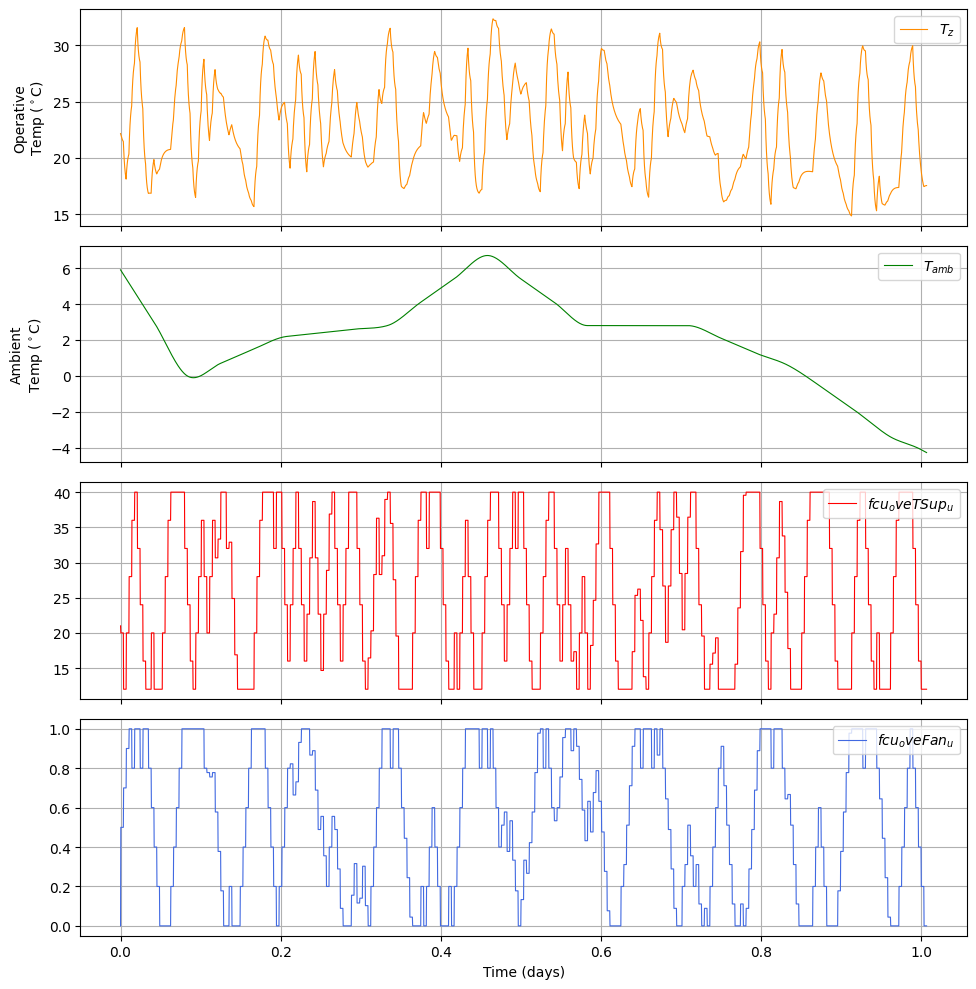

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.15,0.000000e+00,279.050000,0.000000
3801630,295.222125,293.15,5.000000e-01,279.025812,0.000347
3801660,295.117210,293.15,5.000000e-01,279.001625,0.000694
3801690,295.023884,293.15,5.000000e-01,278.977439,0.001042
3801720,294.940950,293.15,5.000000e-01,278.953254,0.001389
...,...,...,...,...,...
3888480,290.678347,285.15,3.278256e-08,268.916667,1.005556
3888510,290.685801,285.15,3.278256e-08,268.908333,1.005903
3888540,290.691559,285.15,3.278256e-08,268.900000,1.006250


In [8]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    
    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

In [9]:
ls_rmse = [t.cpu()*30 for t in ls_rmse]

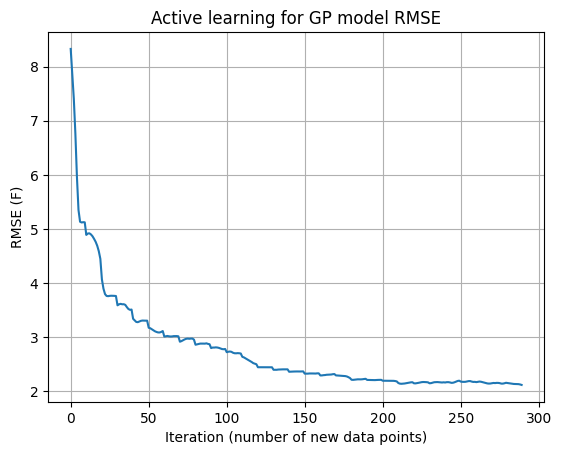

In [10]:

plt.plot(ls_rmse[:1000])
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title('Active learning for GP model RMSE')
plt.show()

In [11]:
df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_AL_GP"])
file_name = f"RMSE_IDW_GP_ini{Ne_tr}_{const.ramp}.csv"
save_dir = os.path.join(save_dir, file_name)
df.to_csv(save_dir, index=False)